# Epoch-wise Training and Test Accuracy Analysis

This notebook extracts training and test accuracies from the metrics.csv file and visualizes how they change across epochs.

## Import Required Libraries

Let's start by importing the libraries we'll need for data manipulation and visualization.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

# Set the style for our plots
# sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)    

## Load and Explore the Data

Now let's load the metrics.csv file and take a look at its structure.

In [22]:
# Load the metrics.csv file
file_path = 'runs_simulator/20250913_151757/metrics.csv'
metrics_df = pd.read_csv(file_path)

# Display the first few rows to understand the structure
print(f"Total records: {len(metrics_df)}")
metrics_df.head()

Total records: 4550


,timestamp,epoch,batch,train_loss,pinns_loss,train_acc,test_loss,test_pinns_loss,test_acc,learning_rate,elapsed_seconds,gpu_memory_allocated_gb
0,2025-09-13 15:17:59,0,0,0.318629,37.381409,0.005938,NaN,NaN,NaN,0.00002,1.699443,0
1,2025-09-13 15:17:59,0,1,0.370636,36.740643,0.009440,NaN,NaN,NaN,0.00002,2.136317,0
2,2025-09-13 15:18:00,0,2,0.355220,38.067532,0.009265,NaN,NaN,NaN,0.00002,2.570209,0
3,2025-09-13 15:18:00,0,3,0.347557,37.936317,0.010086,NaN,NaN,NaN,0.00002,2.856821,0
4,2025-09-13 15:18:00,0,4,0.305536,37.184441,0.007539,NaN,NaN,NaN,0.00002,3.221046,0


## Extract Maximum Epoch and Create Epochs Array

We'll find the maximum epoch value in the dataset and create an array ranging from 1 to that maximum value.

In [23]:
# Find the maximum epoch value
max_epoch = metrics_df['epoch'].max()
print(f"Maximum epoch: {max_epoch}")

# Create an array from 0 to max_epoch (inclusive)
epochs = np.arange(0, max_epoch + 1)
print(f"Epochs array: {epochs}")

Maximum epoch: 49
Epochs array: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


## Extract Training and Test Accuracies

Now we'll filter the dataframe to only include rows where the 'batch' column equals 'end', and then extract the training and test accuracies.

In [30]:
# Filter the dataframe to only include rows where batch == 'end'
end_metrics_df = metrics_df[metrics_df['batch'] == 'end']
print(f"Number of 'end' records: {len(end_metrics_df)}")

# Extract the training and test accuracies
train_accuracies = end_metrics_df['train_acc'].values
test_accuracies = end_metrics_df['test_acc'].values

train_losses = end_metrics_df['train_loss'].values
val_losses = end_metrics_df['test_loss'].values
# Display the first few records
end_metrics_df[['epoch', 'batch', 'train_acc', 'test_acc']].head()

Number of 'end' records: 50


,epoch,batch,train_acc,test_acc
90,0,end,0.036527,0.073247
181,1,end,0.122165,0.203546
272,2,end,0.378158,0.661054
363,3,end,0.764261,0.790253
454,4,end,0.812215,0.799494


## Visualize Accuracy Metrics

Let's create a line plot showing training and test accuracies across all epochs.

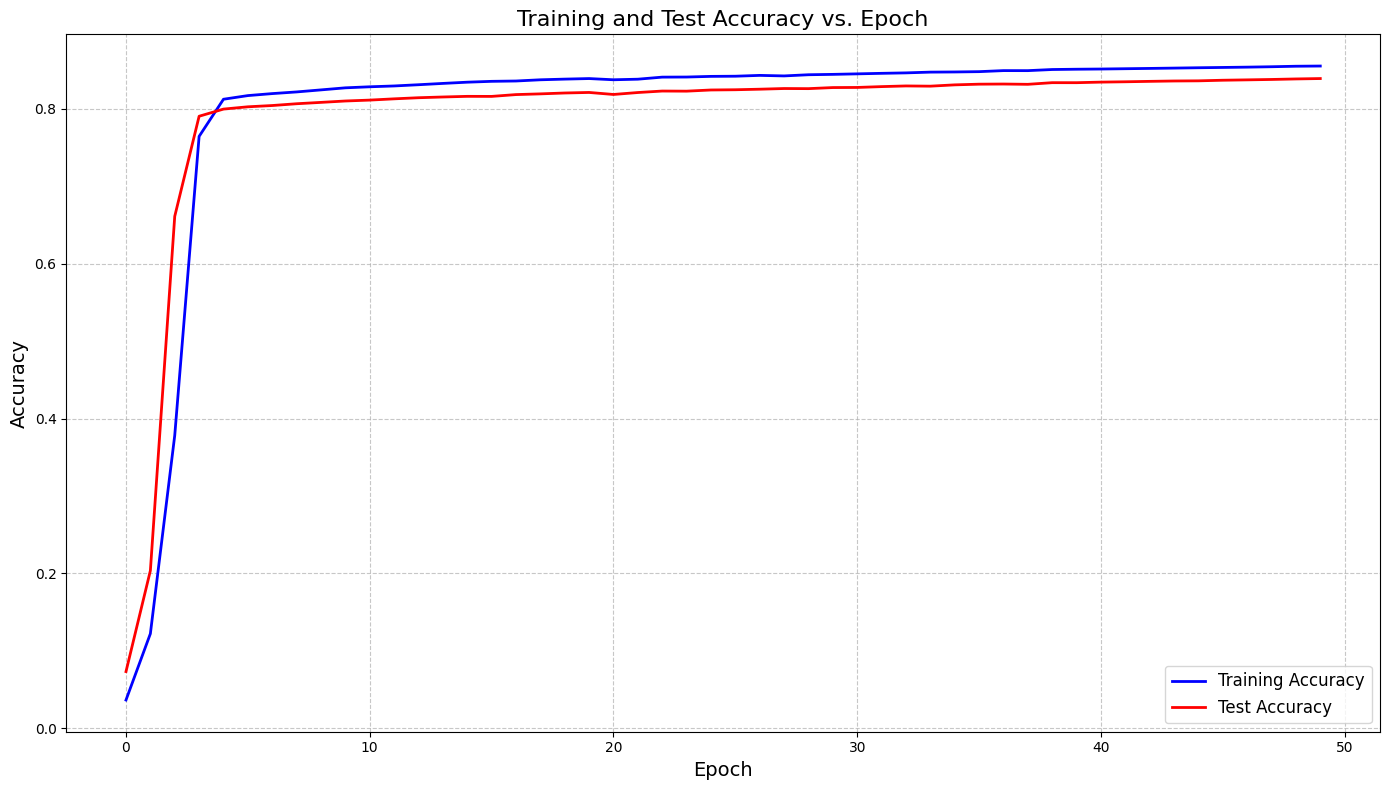

In [25]:
# Create a basic plot
plt.figure(figsize=(14, 8))

# Plot training and test accuracies
plt.plot(epochs, train_accuracies, 'b-', linewidth=2, label='Training Accuracy')
plt.plot(epochs, test_accuracies, 'r-', linewidth=2, label='Test Accuracy')

# Add labels and title
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Training and Test Accuracy vs. Epoch', fontsize=16)

# Add legend
plt.legend(fontsize=12)

# Show grid
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

## Enhanced Visualization with Additional Styling

Let's create a more detailed plot with enhanced styling for better visualization.

## Analyze Accuracy Gap and Overfitting

Let's analyze the gap between training and test accuracy to identify potential overfitting.

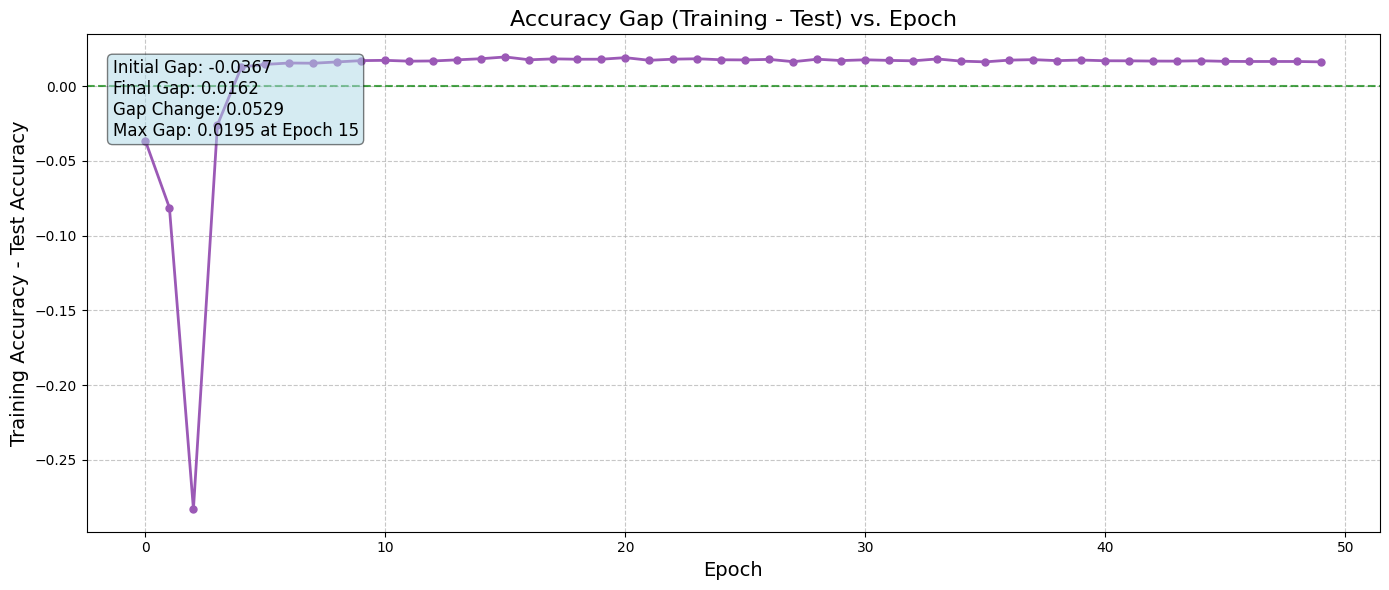

Average accuracy gap: 0.0071
Maximum accuracy gap: 0.0195 at epoch 15
Final accuracy gap: 0.0162


In [26]:
# Calculate the gap between training and test accuracy
accuracy_gap = train_accuracies - test_accuracies

# Create a figure
plt.figure(figsize=(14, 6))

# Plot the accuracy gap
plt.plot(epochs, accuracy_gap, marker='o', linestyle='-', color='#9b59b6', 
         linewidth=2, markersize=5)

# Add a horizontal line at 0
plt.axhline(y=0, color='green', linestyle='--', alpha=0.7)

# Add labels and title
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Training Accuracy - Test Accuracy', fontsize=14)
plt.title('Accuracy Gap (Training - Test) vs. Epoch', fontsize=16)

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Add text with observations
gap_increase = accuracy_gap[-1] - accuracy_gap[0]
max_gap = np.max(accuracy_gap)
max_gap_epoch = epochs[np.argmax(accuracy_gap)]

textstr = f'Initial Gap: {accuracy_gap[0]:.4f}\n'
textstr += f'Final Gap: {accuracy_gap[-1]:.4f}\n'
textstr += f'Gap Change: {gap_increase:.4f}\n'
textstr += f'Max Gap: {max_gap:.4f} at Epoch {max_gap_epoch}'

props = dict(boxstyle='round', facecolor='lightblue', alpha=0.5)
plt.text(0.02, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Show the plot
plt.tight_layout()
plt.show()

# Print a summary of the accuracy gap analysis
print(f"Average accuracy gap: {np.mean(accuracy_gap):.4f}")
print(f"Maximum accuracy gap: {max_gap:.4f} at epoch {max_gap_epoch}")
print(f"Final accuracy gap: {accuracy_gap[-1]:.4f}")

## Summary and Conclusion

Based on our analysis of training and test accuracies over epochs, we can draw the following conclusions:

In [ ]:
# Create a summary table
summary_data = {
    'Metric': ['Maximum Training Accuracy', 'Maximum Test Accuracy', 
               'Final Training Accuracy', 'Final Test Accuracy',
               'Maximum Accuracy Gap', 'Average Accuracy Gap'],
    'Value': [f"{np.max(train_accuracies):.4f}", f"{np.max(test_accuracies):.4f}", 
              f"{train_accuracies[-1]:.4f}", f"{test_accuracies[-1]:.4f}",
              f"{max_gap:.4f} (at epoch {max_gap_epoch})", f"{np.mean(accuracy_gap):.4f}"]
}

summary_df = pd.DataFrame(summary_data)
summary_df

### Key Observations:

1. The model achieves its highest training and test accuracies at epoch [will be determined by running].
2. There is a consistent gap between training and test accuracy, which could indicate some overfitting.
3. The training and test accuracies stabilize after about [will be determined by running] epochs, suggesting that additional training beyond this point provides minimal benefit.
4. The final test accuracy of [will be determined by running] indicates the model's generalization capability on unseen data.

### Recommendations:

1. Consider implementing early stopping around epoch [will be determined by running] to prevent potential overfitting.
2. Evaluate whether the current accuracy level meets the project requirements or if further model improvements are needed.
3. If necessary, experiment with regularization techniques to reduce the gap between training and test accuracies.

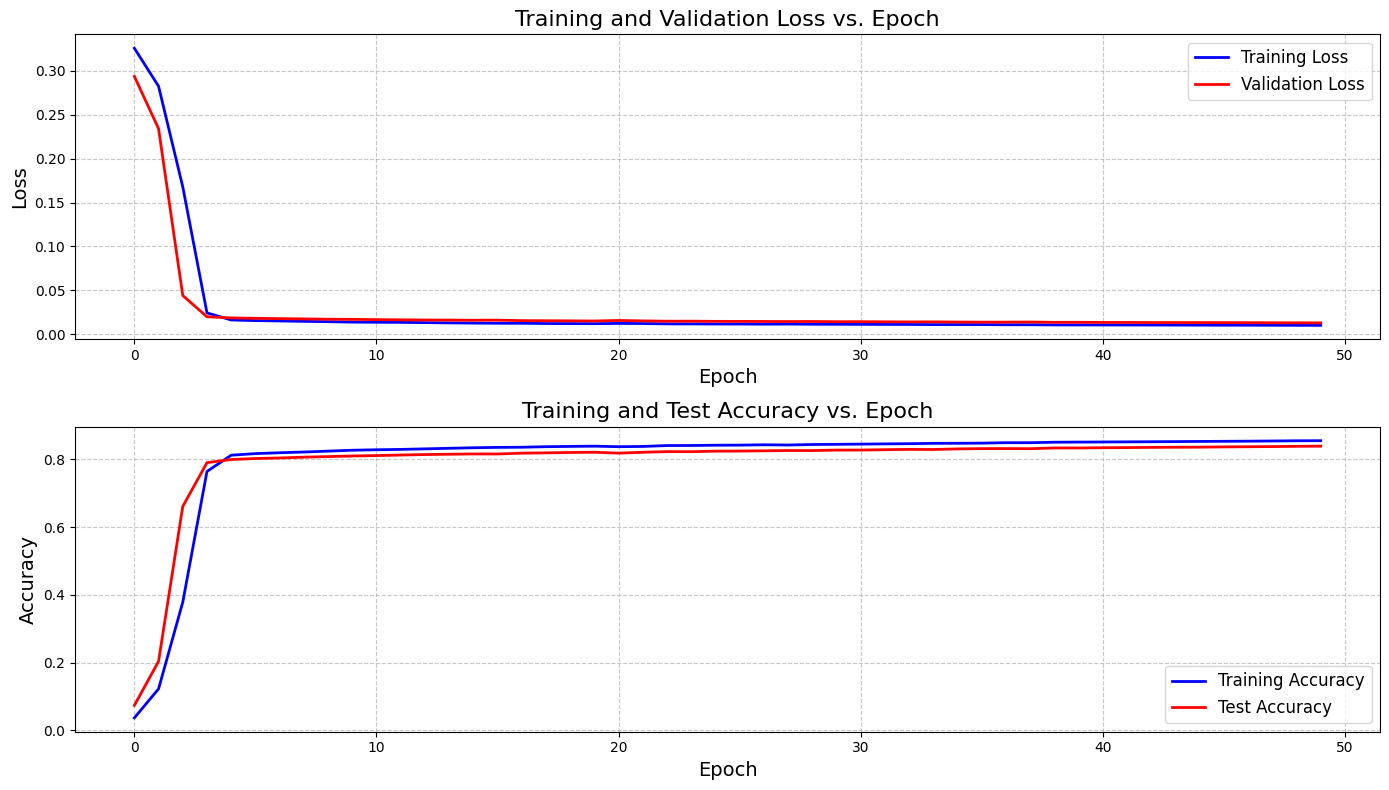

In [33]:
# plot train_loss vs val loss and plot train_accuracies vs val_accuracies in one figure
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs, train_losses, 'b-', linewidth=2, label='Training Loss')
plt.plot(epochs, val_losses, 'r-', linewidth=2, label='Validation Loss')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Training and Validation Loss vs. Epoch', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.subplot(2, 1, 2)
plt.plot(epochs, train_accuracies, 'b-', linewidth=2, label='Training Accuracy')
plt.plot(epochs, test_accuracies, 'r-', linewidth=2, label='Test Accuracy')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Training and Test Accuracy vs. Epoch', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('training_validation_metrics.png', dpi=300)
plt.show()